In [49]:
import pandas as pd
import os
from tqdm import tqdm
from glob import glob
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt

In [18]:
metadata_path = "../../data/Figure5_CASP_ProteinGym/ProteinGym/DMS_substitutions.mmseqs_filtered.reannotated.csv"
metadata_df = pd.read_csv(metadata_path)
metadata_df = metadata_df.set_index('DMS_id')
metadata_df['MSA_Neff_L_category'] = metadata_df['MSA_Neff_L_category'].map(lambda x: str(x).title())

baseline_df = pd.read_csv("../../data/Figure5_CASP_ProteinGym/ProteinGym/SBS_model_spearman_rho.csv", index_col=0)
results_files_l = glob("results/proteingym_uniref_og/*.csv")
baseline_df.loc['MSA Pairformer'] = np.nan
for file in tqdm(results_files_l):
    exp_name = os.path.basename(file).split('.csv')[0]
    res_df = pd.read_csv(file)
    rho, pval = spearmanr(res_df['MSA_model'], res_df['DMS_score'])
    baseline_df.loc["MSA Pairformer", exp_name] = rho

results_files_l = glob("results/proteingym_logan/*.csv")
baseline_df.loc['MSA Pairformer (Logan)'] = np.nan
for file in tqdm(results_files_l):
    exp_name = os.path.basename(file).split('.logan.csv')[0]
    res_df = pd.read_csv(file)
    rho, pval = spearmanr(res_df['mutation_score'], res_df['DMS_score'])
    baseline_df.loc["MSA Pairformer (Logan)", exp_name] = rho


baseline_df = baseline_df.T
baseline_df['coarse_selection_type'] = baseline_df.index.map(lambda x: metadata_df.loc[x, 'coarse_selection_type'])
baseline_df['MSA_Neff_L_category'] = baseline_df.index.map(lambda x: metadata_df.loc[x, 'MSA_Neff_L_category'])
baseline_df['taxon'] = baseline_df.index.map(lambda x: metadata_df.loc[x, 'taxon'])
baseline_df['UniProt_ID'] = baseline_df.index.map(lambda x: metadata_df.loc[x, 'UniProt_ID'])


  0%|          | 0/217 [00:00<?, ?it/s]

100%|██████████| 217/217 [00:08<00:00, 24.75it/s]


In [47]:
copy_baseline_df = baseline_df.copy()
# For each coarse_selection_type, first average within UniProt_ID, then average across UniProt_ID per type.

# Get all the columns that are numeric and relevant
value_columns = [col for col in copy_baseline_df.columns if col not in ['coarse_selection_type', 'MSA_Neff_L_category', 'taxon', 'UniProt_ID'] and copy_baseline_df[col].dtype in ['float64', 'float32', 'int64', 'int32']]

# First, group by ['coarse_selection_type', 'UniProt_ID'] and average
grouped_uni = copy_baseline_df.groupby(['coarse_selection_type', 'UniProt_ID'])[value_columns].mean()

# Next, for each coarse_selection_type, average across all UniProt_ID
avg_by_coarse = grouped_uni.groupby('coarse_selection_type').mean()

methods_l = ['MSA Pairformer', 'MSA Pairformer (Logan)', 'MSA_Transformer_ensemble', 'MSA_Transformer_single', 'ESMC-600M', 'ESMC-300M', 'ESM2_15B', 'ESM2_3B', 'ESM2_150M', 'ESM2_650M']
model_averages_s = avg_by_coarse[methods_l].sort_values(by='ESMC-600M', ascending=False).mean().sort_values(ascending=False)
mean_spearman_s = avg_by_coarse.mean(axis=0)
avg_by_coarse[methods_l].loc[['Activity', 'OrganismalFitness', 'Binding', 'Expression', 'Stability']][methods_l].T

coarse_selection_type,Activity,OrganismalFitness,Binding,Expression,Stability
MSA Pairformer,0.485735,0.451423,0.361730,0.437756,0.506818
MSA Pairformer (Logan),0.498227,0.461789,0.357230,0.447078,0.498772
MSA_Transformer_ensemble,0.473031,0.418766,0.328755,0.445991,0.492063
MSA_Transformer_single,0.454865,0.412018,0.311446,0.429270,0.475263
ESMC-600M,0.422879,0.361804,0.293606,0.419958,0.527707
ESMC-300M,0.422567,0.359965,0.315159,0.407609,0.525709
ESM2_15B,0.404630,0.387376,0.316935,0.405261,0.487545
ESM2_3B,0.417068,0.378371,0.321186,0.402855,0.509062
ESM2_150M,0.391363,0.304680,0.326123,0.401919,0.509920
ESM2_650M,0.425383,0.368352,0.336602,0.415110,0.523273


In [ ]:
copy_baseline_df = baseline_df.copy()
# For each coarse_selection_type, first average within UniProt_ID, then average across UniProt_ID per type.

# Get all the columns that are numeric and relevant
value_columns = [col for col in copy_baseline_df.columns if col not in ['coarse_selection_type', 'MSA_Neff_L_category', 'taxon', 'UniProt_ID'] and copy_baseline_df[col].dtype in ['float64', 'float32', 'int64', 'int32']]

# First, group by ['taxon', 'UniProt_ID'] and average
grouped_uni = copy_baseline_df.groupby(['taxon', 'UniProt_ID'])[value_columns].mean()

# Next, for each taxon, average across all UniProt_ID
avg_by_taxon = grouped_uni.groupby('taxon').mean()

model_averages_s = avg_by_taxon[methods_l].sort_values(by='ESMC-600M', ascending=False).mean().sort_values(ascending=False)
avg_by_taxon[methods_l].loc[['Human', 'Eukaryote', 'Prokaryote', 'Virus']][methods_l].T

taxon,Human,Eukaryote,Prokaryote,Virus
MSA Pairformer,0.456260,0.530322,0.454648,0.470743
MSA Pairformer (Logan),0.454583,0.527119,0.463567,0.486657
MSA_Transformer_ensemble,0.439008,0.515506,0.446125,0.421128
MSA_Transformer_single,0.429578,0.501028,0.425744,0.405885
ESMC-600M,0.462122,0.480716,0.458551,0.240586
ESMC-300M,0.467966,0.480625,0.441433,0.241761
ESM2_15B,0.431640,0.467183,0.436241,0.332799
ESM2_3B,0.442195,0.476684,0.458472,0.294317
ESM2_150M,0.450156,0.474465,0.398267,0.157142
ESM2_650M,0.457167,0.486313,0.457479,0.261076


In [57]:
# Load CASP15 results
results_df = pd.read_csv("results/CASP15_contact_predictions.tsv", index_col=0, sep="\t")
# Subset for targets predicted by all methods
results_df = results_df.dropna(axis=0)
print(f"Number of targets predicted by all methods: {len(results_df)}")
long_pl_s = results_df[[c for c in results_df.columns if "long" in c]].median(axis=0)
long_pl_s.index = long_pl_s.index.map(lambda x: x.replace(" long", ""))
long_pl_d = long_pl_s.to_dict()
long_pl_s

Number of targets predicted by all methods: 45


MSA Pairformer             0.660274
MSA Pairformer (Logan)     0.706849
MSA Transformer            0.500000
MSA Transformer (Logan)    0.552734
ESM2 150M                  0.376682
ESM2 300M                  0.487805
ESM2 650M                  0.467391
ESM2 3B                    0.487805
ESM2 15B                   0.501465
ESMC 300M                  0.458984
ESMC 600M                  0.482422
dtype: float64

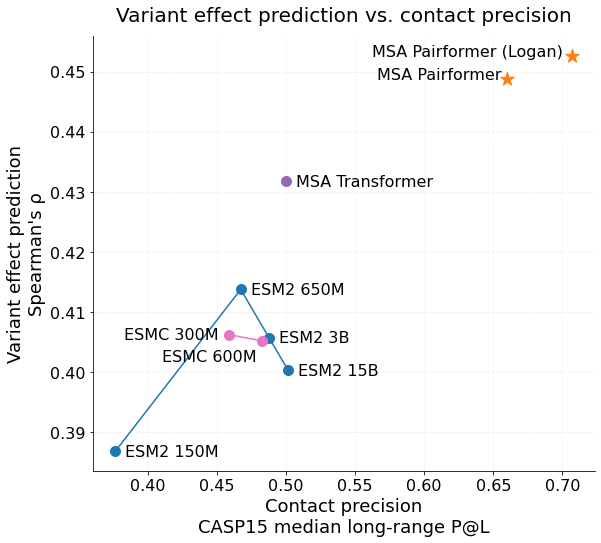

In [59]:
f, ax = plt.subplots(1, 1, figsize=(9, 8))
# Plot ESM2 models
esm_model_names_l = ['ESM2 150M', 'ESM2 650M', 'ESM2 3B', 'ESM2 15B']
# Plot ESM2 models with labels
esm_y = [mean_spearman_s.loc[m.replace(" ", "_")] for m in esm_model_names_l]
esm_y_casp15 = [long_pl_d[m] for m in esm_model_names_l]
ax.plot(esm_y_casp15, esm_y, 'o-', markersize=10)
# Add labels for each point
for i, model_name in enumerate(esm_model_names_l):
    ax.annotate(
        model_name.replace("_", " "), (esm_y_casp15[i], esm_y[i]), 
        textcoords="offset points", 
        xytext=(10, -5), 
        ha='left',
        size=16
    )
# Plot ESM2 models
esm_model_names_l = ['ESMC 300M', 'ESMC 600M']
# Plot ESM2 models with labels
esm_y = [mean_spearman_s.loc[m.replace(" ", "-")] for m in esm_model_names_l]
esm_y_casp15 = [long_pl_d[m] for m in esm_model_names_l]
ax.plot(esm_y_casp15, esm_y, 'o-', markersize=10, color="C6")
# Add labels for each point
# for i, model_name in enumerate(esm_model_names_l):
ax.annotate(
    "ESMC 300M", (esm_y_casp15[0], esm_y[0]), 
    textcoords="offset points", 
    xytext=(-105, -5), 
    ha='left',
    size=16,
)
ax.annotate(
    "ESMC 600M", (esm_y_casp15[1], esm_y[1]), 
    textcoords="offset points", 
    xytext=(-100, -20), 
    ha='left',
    size=16,
)
# Plot MSA Transformer
ax.scatter(long_pl_d["MSA Transformer"], mean_spearman_s.loc["MSA_Transformer_ensemble"], color="C4", marker="o", s=100)
ax.annotate(
    "MSA Transformer", (long_pl_d["MSA Transformer"], mean_spearman_s.loc["MSA_Transformer_ensemble"]), 
    textcoords="offset points", 
    xytext=(10, -5), 
    ha='left',
    size=16
)
# Plot MSA pairformer
ax.scatter(long_pl_d["MSA Pairformer"], mean_spearman_s.loc["MSA Pairformer"], color="C1", marker="*", s=200)
ax.annotate(
    "MSA Pairformer",
    (long_pl_d["MSA Pairformer"], mean_spearman_s.loc["MSA Pairformer"]), 
    textcoords="offset points", 
    xytext=(-130, 0), 
    ha='left',
    size=16
)
# Plot MSA pairformer Logan
ax.scatter(long_pl_d["MSA Pairformer (Logan)"], mean_spearman_s.loc["MSA Pairformer (Logan)"], color="C1", marker="*", s=200)
ax.annotate(
    "MSA Pairformer (Logan)",
    (long_pl_d["MSA Pairformer (Logan)"], mean_spearman_s.loc["MSA Pairformer (Logan)"]), 
    textcoords="offset points", 
    xytext=(-200, 0), 
    ha='left',
    size=16
)
ax.set_ylabel("Variant effect prediction\nSpearman's ρ", size=18)
ax.set_xlabel("Contact precision\nCASP15 median long-range P@L", size=18)
ax.set_title("Variant effect prediction vs. contact precision", size=20, y=1.02)
# Increase tick label size
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=16)
# Format y-axis tick labels to show only hundredths place
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
# Add grid with fainter lines
ax.grid(True, alpha=0.15, linestyle='--')
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)